### Importing

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Dataset.csv")
df.head()

,x,y
0,0.496714,4.861736
1,0.647689,6.523030
2,-0.234153,4.765863
3,1.579213,5.767435
4,-0.469474,5.542560


### EDA

In [35]:
df.shape

(150, 2)

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.isnull().sum()

x    0
y    0
dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       150 non-null    float64
 1   y       150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
x,150.0,-0.083223,2.612546,-4.839943,-2.366776,-0.053918,2.281063,5.037727
y,150.0,1.730307,2.473526,-3.158555,-0.237809,0.832002,4.417004,6.852278


In [40]:
data = df.values

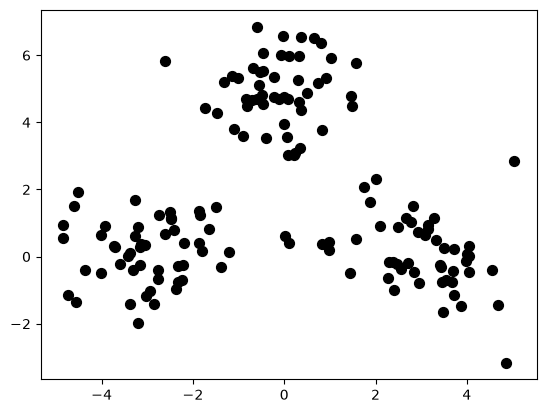

In [41]:
plt.scatter(data[: , 0] , data[: , 1] , s = 50 , color = "black")
plt.show()

### Elbow Method

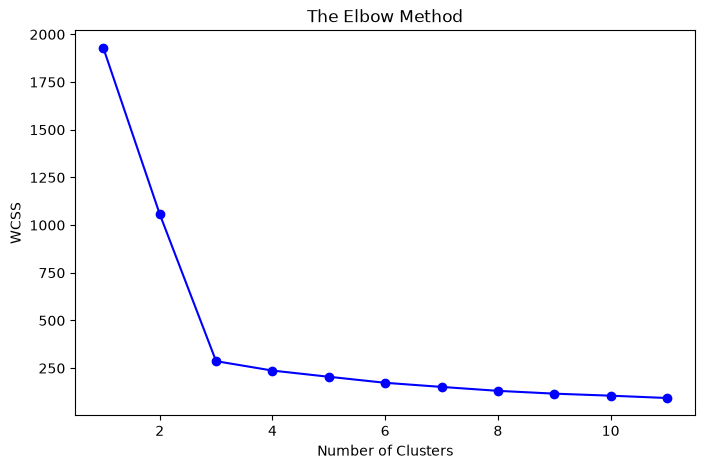

In [42]:
wcss = []

for i in range(1 , 12):
    model = KMeans(n_clusters = i , init = "k-means++" , max_iter = 300 , n_init = 10)
    model.fit(data)
    wcss.append(model.inertia_)

plt.figure(figsize = (8 , 5))
plt.plot(range(1 , 12) , wcss , "bo-")
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Train Model & Visualize Clusters & Evaluation

In [43]:
final_model = KMeans(n_clusters = 3 , init = "k-means++" , n_init = 10 , max_iter = 300 , random_state = 101)
result = final_model.fit_predict(data)

In [44]:
print(f"Silhouette Score : {silhouette_score(data , result)}")

Silhouette Score : 0.670830896849684


In [45]:
df["cluster"] = result

In [46]:
df["cluster"].value_counts()

cluster
1    50
0    50
2    50
Name: count, dtype: int64

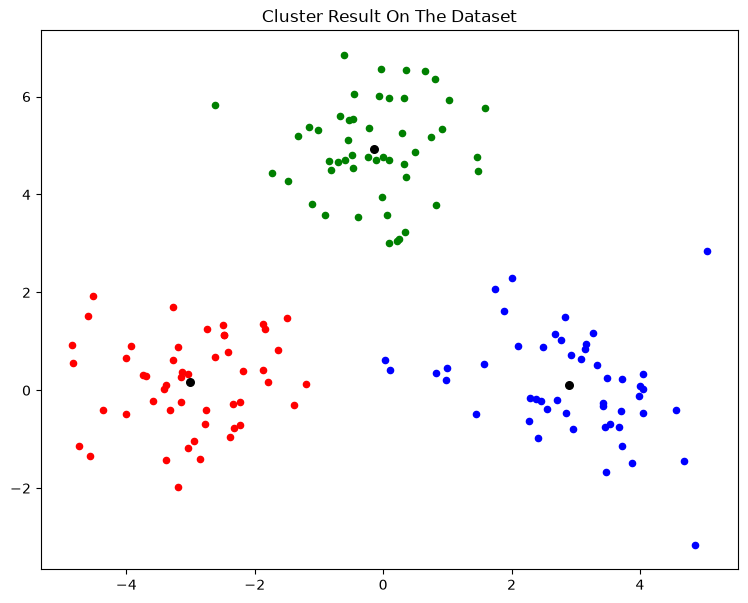

In [48]:
plt.figure(figsize = (9 , 7))
plt.scatter(data[result == 0 , 0] , data[result == 0 , 1] , s = 20 , c = "red")
plt.scatter(data[result == 1 , 0] , data[result == 1 , 1] , s = 20 , c = "green")
plt.scatter(data[result == 2 , 0] , data[result == 2 , 1] , s = 20 , c = "blue")
plt.scatter(final_model.cluster_centers_[: , 0] , final_model.cluster_centers_[: , 1] , s = 30 , c = "black")

plt.title("Cluster Result On The Dataset")
plt.show()